# **CAPSTONE 2**

**Analyst:** Jessica Navarro

**Territory Manager:** Jim Heck

**Territory Director:** Cassie Chambers

**Territories Analyzed:**
- (West) COLORADO
- (South) TEXAS


Objective: I've analyzed the bookstore's EmporiUm sales data in two specific regions, West and South, using both Python and Jupyter Notebook. I studied the store performance, monthly sales, product categories, transactions, and top customers to gain marketing insights from the data set.

In [279]:
# Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Formatting numbers as currency and decimals as needed
pd.options.display.float_format = '${:,.2f}'.format

In [280]:
# Load the files
stores = pd.read_csv("StoreDetail.csv")
sales = pd.read_csv("StoreSales.csv")
customers = pd.read_csv("customer_list.csv", sep="|")
products = pd.read_csv("Products.csv")
categories = pd.read_csv("ProductCategories.csv")

# Clean column names
stores.columns = stores.columns.str.strip()
sales.columns = sales.columns.str.strip()
customers.columns = customers.columns.str.strip()
products.columns = products.columns.str.strip()
categories.columns = categories.columns.str.strip()

In [281]:
# Change dates into real date format
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])

# Create a month column for monthly charts
sales["Month"] = sales["Transaction Date"].dt.to_period("M").astype(str)

In [282]:
# Merge sales with store details
sales_stores = sales.merge(stores, on="Store ID", how="left")

# Filtering for Jim Heck's and Jeff Richards's territories
my_territories = sales_stores[
    ((sales_stores["Territory Manager"] == "Jim Heck") &
    (sales_stores["State"] == "Colorado") & (sales_stores["Region"] == "West"))
    |
    ((sales_stores["Territory Manager"] == 'Jeff "Howdy" Richards') &
    (sales_stores["State"] == "Texas") & (sales_stores["Region"] == "South"))]

# Show a clean table with no index
display(my_territories.head(10).style.hide(axis="index"))


# Jeff managed stores diplayed ONLY:
jeff_rows = my_territories[
    my_territories["Territory Manager"] == 'Jeff "Howdy" Richards'
]

display(jeff_rows.head(10).style.hide(axis="index"))

Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
2022-01-01 00:00:00,702,nan,105349-M,8.000000,2022-01,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,704,nan,105350-T,144.000000,2022-01,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105351-M,44.000000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105352-M,47.610000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105353-A,20.360000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,706,nan,105344-IT,265.070000,2022-01,Englewood,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,707,nan,105354-T,133.100000,2022-01,Fort Collins,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,707,nan,105355-B,24.280000,2022-01,Fort Collins,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,708,nan,105356-S,13.130000,2022-01,Grand Junction,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,709,nan,105357-T,195.300000,2022-01,Greeley,Colorado,Jim Heck,West,Cassie Chambers


Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
2022-01-01 00:00:00,902,nan,105454-M,14.000000,2022-01,Austin,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,904,nan,105326-IT,1717.700000,2022-01,Baytown,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105347-IT,837.520000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105348-IT,29.810000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105432-S,6.020000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,907,nan,105413-A,57.700000,2022-01,Dallas,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,908,328.000000,105337-IT,1301.880000,2022-01,Denton,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,908,nan,105445-T,178.600000,2022-01,Denton,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,909,nan,105455-S,10.100000,2022-01,Desoto,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,910,nan,105456-T,60.720000,2022-01,Fort Worth,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


# **CORE MARKETING ANALYSIS**

# Question 1: Territory Managers and Stores

Objective:
*I want to identify for each territory*:
- *territory managers*
- *store IDs*
- *store locations*


Territories:
- **Assigned:** *Jim Heck (Colorado - West)*
-  **Comparison:** *Jeff Richards (Texas - South)*

In [283]:
# UPDATED!!!!!!
# Filtering stores in my assigned territories

territory_stores = stores[((stores["Territory Manager"] == "Jim Heck") &
        (stores["State"] == "Colorado"))
    |
    ((stores["Territory Manager"] == 'Jeff "Howdy" Richards') &
        (stores["State"] == "Texas"))]

display(
    territory_stores[
        ["Territory Manager", "Store ID", "Store Location", "State", "Region"]
    ]
    .sort_values(["Territory Manager", "Store ID"])
    .style.hide(axis="index"))

Territory Manager,Store ID,Store Location,State,Region
"Jeff ""Howdy"" Richards",901,Arlington,Texas,South
"Jeff ""Howdy"" Richards",902,Austin,Texas,South
"Jeff ""Howdy"" Richards",903,Bacliff,Texas,South
"Jeff ""Howdy"" Richards",904,Baytown,Texas,South
"Jeff ""Howdy"" Richards",905,Beaumont,Texas,South
"Jeff ""Howdy"" Richards",906,Cedar Park,Texas,South
"Jeff ""Howdy"" Richards",907,Dallas,Texas,South
"Jeff ""Howdy"" Richards",908,Denton,Texas,South
"Jeff ""Howdy"" Richards",909,Desoto,Texas,South
"Jeff ""Howdy"" Richards",910,Fort Worth,Texas,South


So, this table shows all stores managed by Jim Heck and Jeff Richards.
These stores will be used throughout the rest of the analysis.

# Question 2: Monthly Revenue

Objective:

*I want to compare monthly sales revenue between the two territories. This will help identify sales trends over time.*

In [284]:
# Monthly revenue

monthly_revenue = my_territories.groupby(
    ["Month", "Territory Manager"],
    as_index=False)["Sale Amount"].sum()

monthly_revenue = monthly_revenue.rename(
    columns={"Sale Amount": "Monthly Revenue"})

display(monthly_revenue.style.hide(axis="index"))

Month,Territory Manager,Monthly Revenue
2022-01,"Jeff ""Howdy"" Richards",40857.200000
2022-01,Jim Heck,77950.980000
2022-02,"Jeff ""Howdy"" Richards",52729.220000
2022-02,Jim Heck,80315.690000
2022-03,"Jeff ""Howdy"" Richards",49214.950000
2022-03,Jim Heck,82516.360000
2022-04,"Jeff ""Howdy"" Richards",55229.250000
2022-04,Jim Heck,89350.310000
2022-05,"Jeff ""Howdy"" Richards",49696.980000
2022-05,Jim Heck,94892.890000


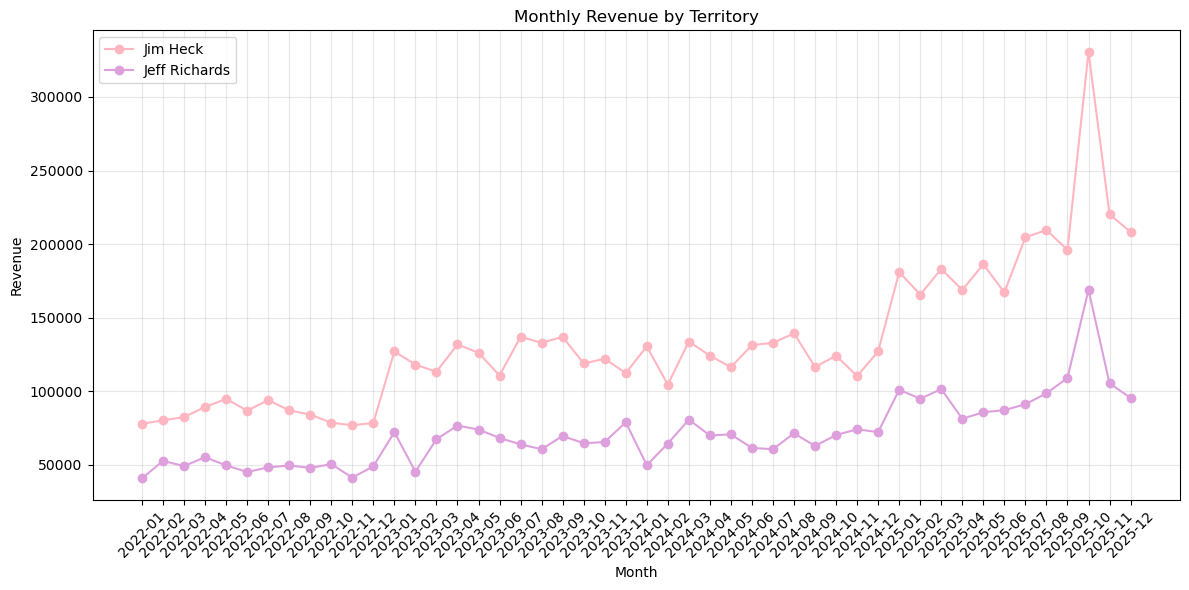

In [285]:
# Monthly revenue line chart

chart_data = monthly_revenue.pivot(
    index="Month",
    columns="Territory Manager",
    values="Monthly Revenue"
)

plt.figure(figsize=(12,6))

plt.plot(
    chart_data.index,
    chart_data["Jim Heck"],
    marker="o",
    color="lightpink",
    label="Jim Heck"
)

plt.plot(
    chart_data.index,
    chart_data['Jeff "Howdy" Richards'],
    marker="o",
    color="plum",
    label="Jeff Richards"
)

plt.title("Monthly Revenue by Territory")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This line chart makes it easy to compare monthly revenue trends between the two territories.

# Question 3: Store Performance

Objective:
*I want to rank stores based on total sales revenue. This helps identify the strongest-performing stores in each territory.*

In [286]:
# Rank stores by revenue

store_rankings = my_territories.groupby(
    ["Territory Manager", "Store ID", "Store Location"],
    as_index=False
)["Sale Amount"].sum()

store_rankings = store_rankings.rename(
    columns={"Sale Amount": "Total Revenue"}
)

store_rankings["Store Rank"] = store_rankings.groupby(
    "Territory Manager"
)["Total Revenue"].rank(
    ascending=False,
    method="dense"
)

store_rankings = store_rankings.sort_values(
    ["Territory Manager", "Store Rank"]
)

display(store_rankings.style.hide(axis="index"))

Territory Manager,Store ID,Store Location,Total Revenue,Store Rank
"Jeff ""Howdy"" Richards",905,Beaumont,637818.900000,1.000000
"Jeff ""Howdy"" Richards",910,Fort Worth,351772.590000,2.000000
"Jeff ""Howdy"" Richards",909,Desoto,330720.120000,3.000000
"Jeff ""Howdy"" Richards",906,Cedar Park,312628.270000,4.000000
"Jeff ""Howdy"" Richards",904,Baytown,298163.160000,5.000000
"Jeff ""Howdy"" Richards",908,Denton,298111.450000,6.000000
"Jeff ""Howdy"" Richards",901,Arlington,292987.490000,7.000000
"Jeff ""Howdy"" Richards",902,Austin,291145.000000,8.000000
"Jeff ""Howdy"" Richards",903,Bacliff,280714.340000,9.000000
"Jeff ""Howdy"" Richards",911,Georgetown,269344.640000,10.000000


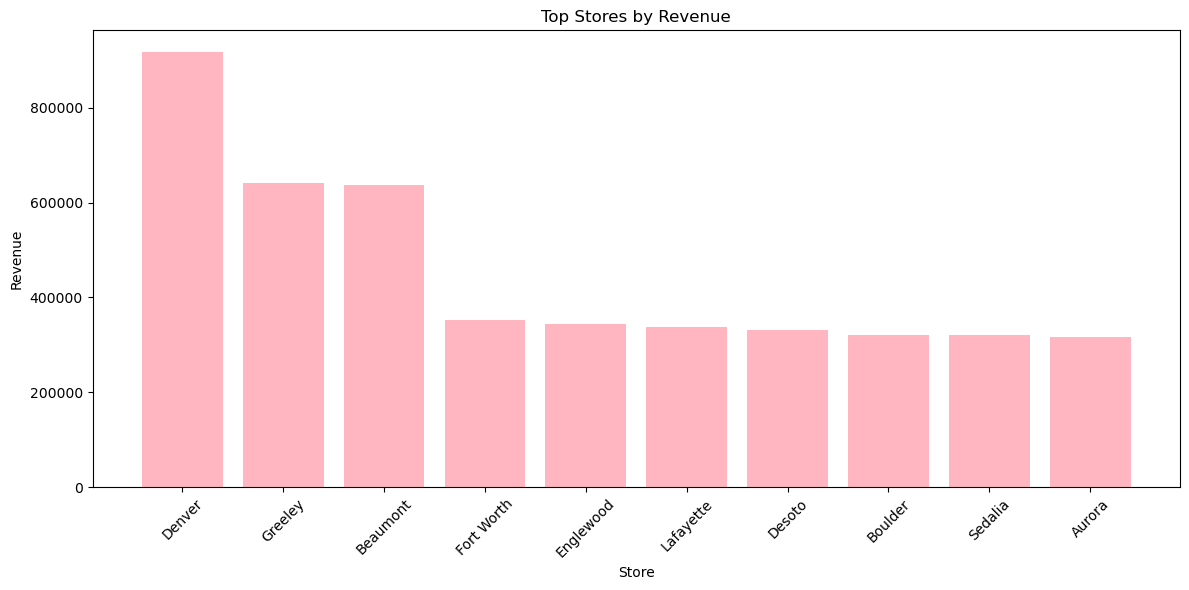

In [287]:
# Top stores chart

top_stores = store_rankings.sort_values(
    "Total Revenue",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_stores["Store Location"],
    top_stores["Total Revenue"],
    color="lightpink"
)

plt.title("Top Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Question 4: Top Customers

Objective: *I want to identify the rewards customers who spent the most money. This can help marketing target valuable customers.*

In [295]:
#kept giving me an error when I tried to run the code with Jeff's name as "Jeff Richards" instead of 'Jeff "Howdy" Richards' so I changed it in the code and it worked!
# I also updated the line chart to reflect the name change.
# Check exact column names
customers.columns

# Merge customer information
sales_customers = my_territories.merge(
    customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="left")

# Find top rewards customers
top_customers = sales_customers.groupby(
    ["cust_id", "name", "email"],
    as_index=False)["Sale Amount"].sum()

# Rename column
top_customers = top_customers.rename(
    columns={"Sale Amount": "Total Spend"})

# Sort highest spenders first
top_customers = top_customers.sort_values("Total Spend", ascending=False)

# Show clean table
display(top_customers.head(10).style.hide(axis="index"))

cust_id,name,email,Total Spend
245.000000,Gloria Mendoza,gloria@litchfield.pen,7922.460000
344.000000,Nate Jacobs,nate@easthighland.high,6975.810000
102.000000,Jodie L.,jodie@lawndale.high,5757.770000
128.000000,Sonny Corinthos,sonny@generalhospital.med,5694.260000
375.000000,C.J. Cregg,cj@westwing.gov,5673.450000
501.000000,Betty Ramsey,betty@ricardoproductions.tv,5420.840000
371.000000,Principal Weems,weems@nevermore.academy,5293.450000
409.000000,Gerri Kellman,gerri@waystarroyco.com,5139.990000
171.000000,Clark County,clark@paperboi.atl,4923.840000
242.000000,Lorna Morello,lorna@litchfield.pen,4919.830000


# Question 5: Product Categories

Objective: *I want to determine which product categories generate the most revenue. This can help identify the most popular products.*

In [297]:
sales_products.columns

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount',
       'Month', 'Store Location', 'State', 'Territory Manager', 'Region',
       'Region Director', 'Product', 'CategoryID', 'SubcategoryID_x',
       'Category', 'SubcategoryID_y', 'Subcategory'],
      dtype='object')

In [298]:
# Group sales by product category
category_sales = sales_products.groupby(
    ["Category"],
    as_index=False
)["Sale Amount"].sum()

# Rename column
category_sales = category_sales.rename(
    columns={"Sale Amount": "Revenue"}
)

# Sort highest revenue first
category_sales = category_sales.sort_values(
    "Revenue",
    ascending=False
)

# Show clean table
display(category_sales.style.hide(axis="index"))

Category,Revenue
Technology & Accessories,48994687.910000
Textbooks,18807395.200000
Art Supplies,3969528.420000
Apparel and Merchandise,3535701.840000
Stationery and Supplies,1680853.350000
Books (General),663376.400000


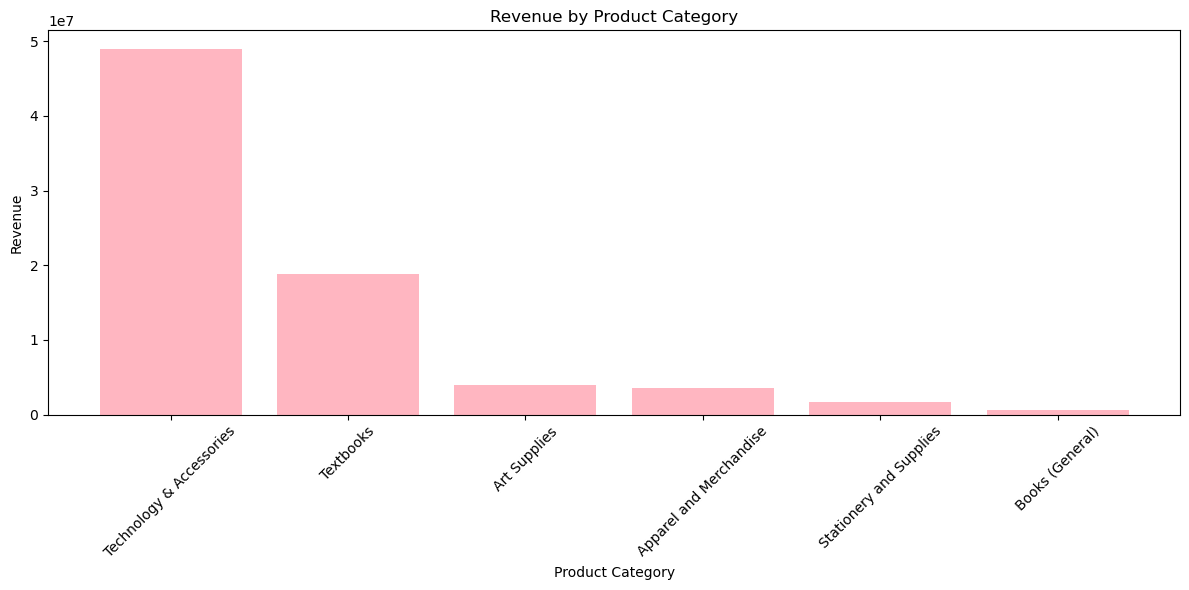

In [299]:
# Bar chart for category revenue
plt.figure(figsize=(12, 6))

plt.bar(
    category_sales["Category"],
    category_sales["Revenue"],
    color="lightpink"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Question 6: Next Quarter Marketing Reccomendation

After analyzing, I think marketing should be focused on:

1. The highest revenue product categories
2. The highest performing stores
3. Retaining top rewards customers

Because these are the areas already making strong revenue AND offer the best opportunity for more growth.

Also, I think more added promotions could be targeted for lower-performing stores to help them increase sales in those locations/territories.